Состав команды: Рябцева Мария, Каминская Таисися(в группе Васильева), Мороз Татьяна

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('spotify2023.csv', encoding='latin1', sep=';')
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,125,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,138,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,170,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5
598,The Nights,Avicii,1,2014,1,1,17354,8,1456081449,126,Major,53,66,85,2,0,24,4


In [ ]:
df.shape

(600, 18)

Можем увидеть, что датасет имеет 600 строк и 18 признаков.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            600 non-null    object
 1   artist(s)_name        600 non-null    object
 2   artist_count          600 non-null    int64 
 3   released_year         600 non-null    int64 
 4   released_month        600 non-null    int64 
 5   released_day          600 non-null    int64 
 6   in_spotify_playlists  600 non-null    int64 
 7   in_spotify_charts     600 non-null    int64 
 8   streams               600 non-null    int64 
 9   bpm                   600 non-null    int64 
 10  mode                  600 non-null    object
 11  danceability_%        600 non-null    int64 
 12  valence_%             600 non-null    int64 
 13  energy_%              600 non-null    int64 
 14  acousticness_%        600 non-null    int64 
 15  instrumentalness_%    600 non-null    in

Можно обнаружить, что в выбранном датасете присутствуют числовые и категориальные данные.


Среди **числовых**: число авторов одной песни, год, месяц, день, сколько раз добавили песню в плейлисты Spotify, сколько раз добавили песню в чарты Spotify, количество прослушиваний, bpm, danceability, valence, energy, acousticness, instrumentalness, liveness, speechiness.\
Из них **дискретными** являются: число авторов одной песни, год, месяц, день, сколько раз добавили песню в плейлисты Spotify, количество прослушиваний, bpm.\
**Непрерывные** же данные представлены признаками: valence, energy, acousticness, instrumentalness, liveness, speechiness.


Среди **категориальных**: названия треков, имя артиста, а также тональности (mode) и место в чартах.\
**Номинальным** являются названия треков и имена артистов, а тональность так же является **бинарными** данными, так как имеет только две вариации: Minor/Major.\
**Порядковыми** являются места в чартах так, как не определен разрыв между соседними местами.

Так как мы удалили неинформативный столбец ***key***, не имеющей веса в анализе, в наших данных нет пропусков (для всех столбцов 600/600 non-null), что еще раз проверено после отчистки данных от выбросов. Ниже код с проверкой.

In [ ]:
df.isna().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
bpm,0


Видим, что по всем признакам 0 пропусков.

# **Выбросы**

Исследуем при помощи *ящиков с усами*.

<Axes: >

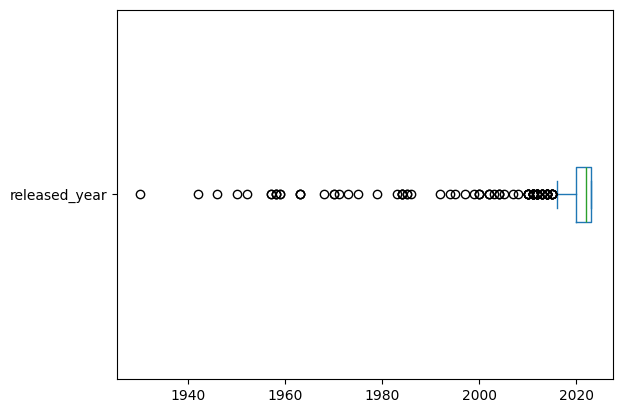

In [ ]:
df['released_year'].plot(kind = 'box', vert = False) #год выпуска песни

<Axes: >

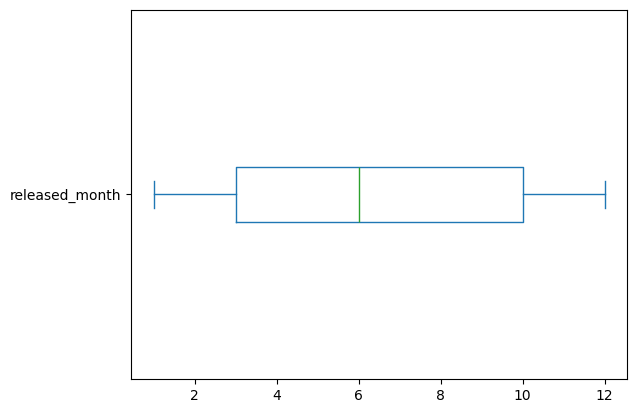

In [ ]:
df['released_month'].plot(kind = 'box', vert = False) #месяц выпуска песни

<Axes: >

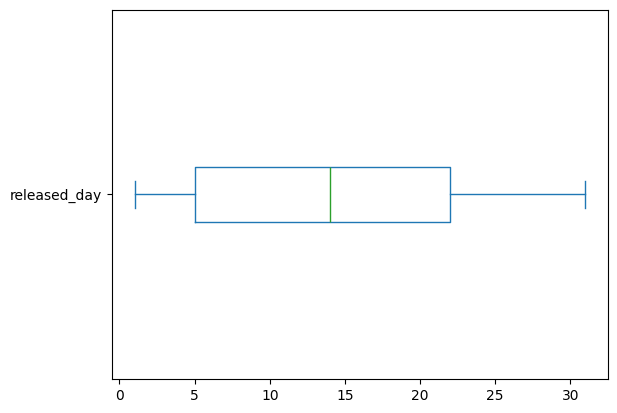

In [ ]:
df['released_day'].plot(kind = 'box', vert = False) #день выпуска песни

<Axes: >

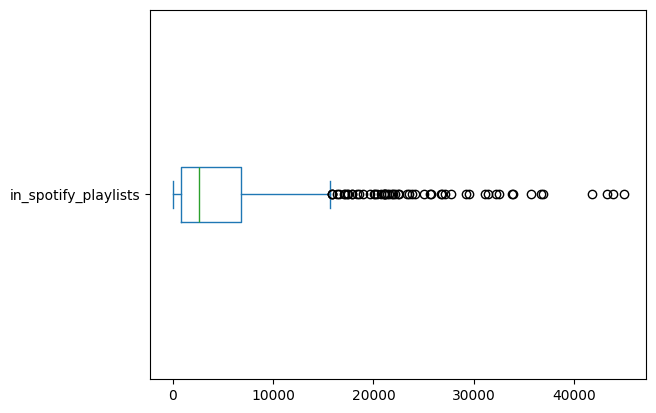

In [ ]:
df['in_spotify_playlists'].plot(kind = 'box', vert = False) #сколько раз добавили песню в плейлисты Spotify

<Axes: >

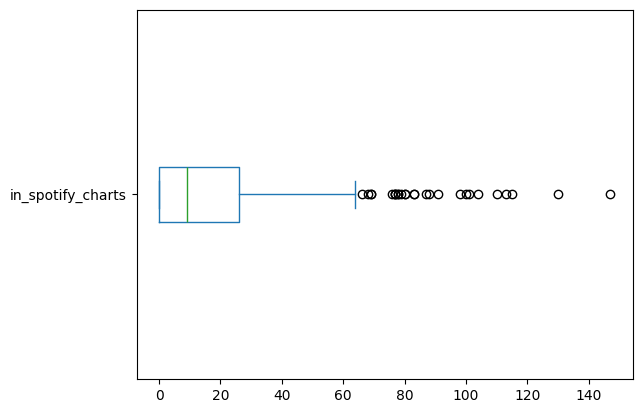

In [ ]:
df['in_spotify_charts'].plot(kind = 'box', vert = False) #сколько раз добавили песню в чарты Spotify

<Axes: >

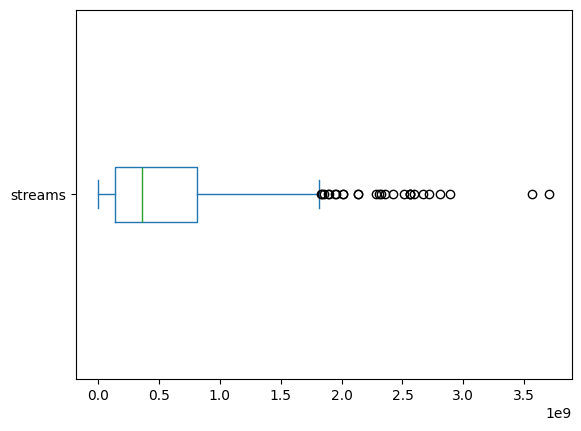

In [ ]:
df['streams'].plot(kind = 'box', vert = False) #количество прослушиваний

<Axes: >

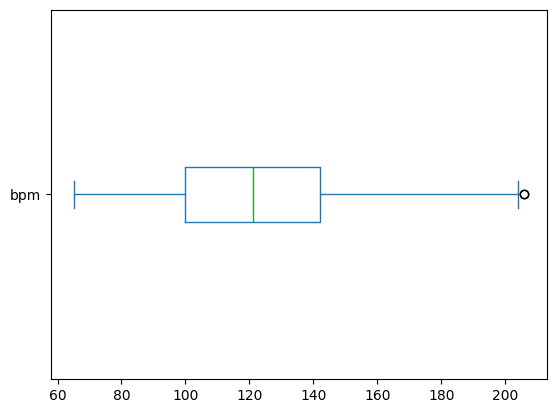

In [ ]:
df['bpm'].plot(kind = 'box', vert = False) #количество ударов в минуту

<Axes: >

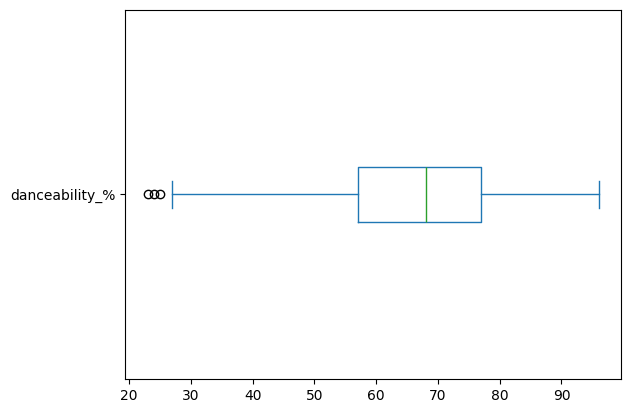

In [ ]:
df['danceability_%'].plot(kind = 'box', vert = False) #danceability

<Axes: >

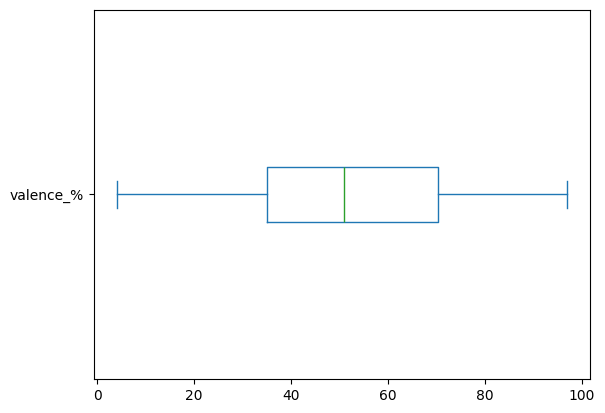

In [ ]:
df['valence_%'].plot(kind = 'box', vert = False) #valence

<Axes: >

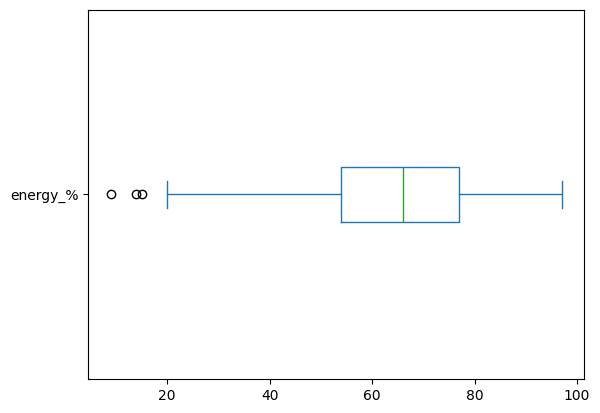

In [ ]:
df['energy_%'].plot(kind = 'box', vert = False) #energy

<Axes: >

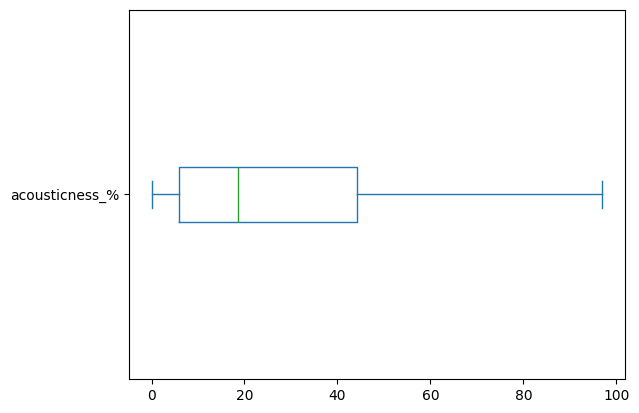

In [ ]:
df['acousticness_%'].plot(kind = 'box', vert = False) #acousticness

<Axes: >

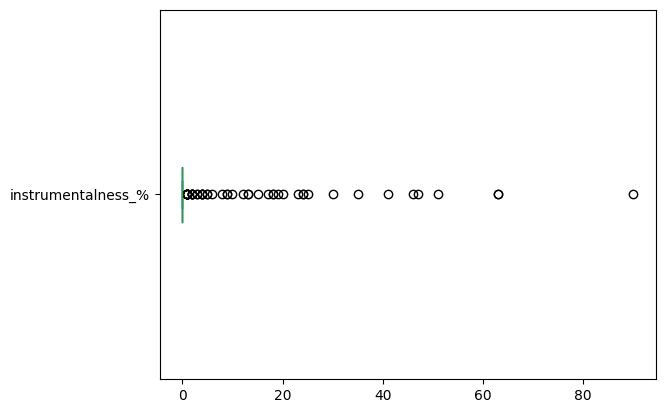

In [ ]:
df['instrumentalness_%'].plot(kind = 'box', vert = False) #instrumentalness

<Axes: >

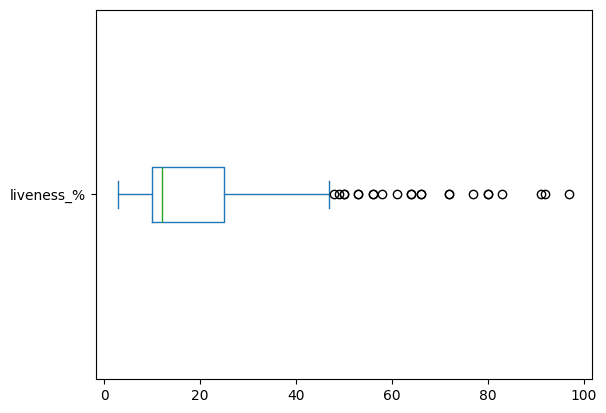

In [ ]:
df['liveness_%'].plot(kind = 'box', vert = False) #liveness

<Axes: >

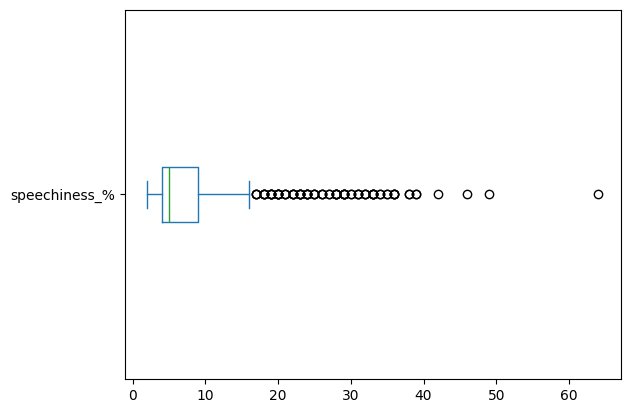

In [ ]:
df['speechiness_%'].plot(kind = 'box', vert = False) #speechiness

Можем заметить, что выбросы есть у следующих признаков: 'released_year', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'bpm', 'danceability_%', 'energy_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'. Обработаем их при помощи метода IQR*1.5.

In [ ]:
q1 = df['in_spotify_playlists'].quantile(0.25)
q3 = df['in_spotify_playlists'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя граница
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_1 = df[(df['in_spotify_playlists']>=low1) & (df['in_spotify_playlists']<=up1)]
df_clean_1

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,125,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,138,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,170,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_1['in_spotify_charts'].quantile(0.25)
q3 = df_clean_1['in_spotify_charts'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_2 = df_clean_1[(df_clean_1['in_spotify_charts']>=low1) & (df_clean_1['in_spotify_charts']<=up1)]
df_clean_2

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,0,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,0,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_2['streams'].quantile(0.25)
q3 = df_clean_2['streams'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_3 = df_clean_2[(df_clean_2['streams']>=low1) & (df_clean_2['streams']<=up1)]
df_clean_3

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,0,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,0,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_3['bpm'].quantile(0.25)
q3 = df_clean_3['bpm'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_4 = df_clean_3[(df_clean_3['bpm']>=low1) & (df_clean_3['bpm']<=up1)]
df_clean_4

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,0,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,0,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_4['danceability_%'].quantile(0.25)
q3 = df_clean_4['danceability_%'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_5 = df_clean_4[(df_clean_4['danceability_%']>=low1) & (df_clean_4['danceability_%']<=up1)]
df_clean_5

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,0,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,0,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_5['energy_%'].quantile(0.25)
q3 = df_clean_5['energy_%'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_6 = df_clean_5[(df_clean_5['energy_%']>=low1) & (df_clean_5['energy_%']<=up1)]
df_clean_6

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,0,10,4
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,144,Minor,65,23,80,14,63,11,6
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,0,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,0,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,0,8,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,0,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,0,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,0,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,0,9,5


In [ ]:
q1 = df_clean_6['instrumentalness_%'].quantile(0.25)
q3 = df_clean_6['instrumentalness_%'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_7 = df_clean_6[(df_clean_6['instrumentalness_%']>=low1) & (df_clean_6['instrumentalness_%']<=up1)]
df_clean_7[df_clean_7['instrumentalness_%']!=0]

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%


Мы видим, что колонка полностью занулилась после удаления выбросов, поэтому принимаем решение удалить данный критерий из выброки так, как он не поддается отчитске с сохранением информативности.

In [ ]:
df_clean_7.drop('instrumentalness_%', axis=1, inplace=True)

<ipython-input-32-6c71fd116e2f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_7.drop('instrumentalness_%', axis=1, inplace=True)


In [ ]:
q1 = df_clean_7['liveness_%'].quantile(0.25)
q3 = df_clean_7['liveness_%'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_8 = df_clean_7[(df_clean_7['liveness_%']>=low1) & (df_clean_7['liveness_%']<=up1)]
df_clean_8

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,10,4
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,11,4
9,La Bebe - Remix,"Peso Pluma, Yng Lvcas",2,2023,3,17,2953,44,553634067,170,Minor,81,56,48,21,8,33
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,83,Minor,57,56,72,23,27,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,9,5


In [ ]:
q1 = df_clean_8['speechiness_%'].quantile(0.25)
q3 = df_clean_8['speechiness_%'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean_9 = df_clean_8[(df_clean_8['speechiness_%']>=low1) & (df_clean_8['speechiness_%']<=up1)]
df_clean_9

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,10,4
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,11,4
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,83,Minor,57,56,72,23,27,5
11,Super Shy,NewJeans,1,2023,7,7,422,55,58255150,150,Minor,78,52,82,18,15,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,6,4
596,Talking To The Moon,Bruno Mars,1,2010,10,4,7109,2,1062956628,146,Minor,52,7,61,51,11,3
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,9,5


In [ ]:
q1 = df_clean_9['released_year'].quantile(0.25)
q3 = df_clean_9['released_year'].quantile(0.75)
iqr = q3-q1
low1 = q1 - iqr*1.5 #нижняя границы
up1 = q3 + iqr*1.5 #верхняя граница
df_clean = df_clean_9[(df_clean_9['released_year']>=low1) & (df_clean_9['released_year']<=up1)]
df_clean

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,10,4
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,11,4
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,83,Minor,57,56,72,23,27,5
11,Super Shy,NewJeans,1,2023,7,7,422,55,58255150,150,Minor,78,52,82,18,15,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,Astronaut In The Ocean,Masked Wolf,1,2019,1,1,7191,0,1138474110,150,Minor,78,47,70,18,15,9
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,6,4
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,9,5


In [ ]:
df_clean.shape

(317, 17)

Таким образом, можно увидеть, что 283 песени мы убрали из списка как выбросы. Теперь в нашем датасете ***317 значений***.

### Отсутствуют полные дубликаты

In [ ]:
df_clean.drop_duplicates(['track_name',	'artist(s)_name',	'artist_count',	'released_year',	'released_month',	'released_day',	'in_spotify_playlists',	'in_spotify_charts',	'streams',	'bpm',	'mode',	'danceability_%',	'valence_%',	'energy_%',	'acousticness_%',	'liveness_%',	'speechiness_%'])

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,10,4
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,8,3
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,11,4
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,83,Minor,57,56,72,23,27,5
11,Super Shy,NewJeans,1,2023,7,7,422,55,58255150,150,Minor,78,52,82,18,15,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,Astronaut In The Ocean,Masked Wolf,1,2019,1,1,7191,0,1138474110,150,Minor,78,47,70,18,15,9
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,13,10
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,6,4
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,9,5


In [ ]:
df_clean.shape

(317, 17)

# Описательная статистика

## Для числовых переменных

In [ ]:
df_clean.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%
count,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,3.170000e+02,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000,317.000000
mean,1.589905,2021.981073,6.429022,14.687697,2487.981073,13.318612,3.519983e+08,122.608833,67.974763,52.996845,64.968454,26.687697,17.126183,6.334385
std,0.911751,1.027912,3.610662,8.967960,2538.166723,14.666635,3.177248e+08,26.636055,12.938242,23.780576,15.754815,25.341970,10.532793,3.592606
min,1.000000,2018.000000,1.000000,1.000000,34.000000,0.000000,2.762000e+03,65.000000,31.000000,4.000000,20.000000,0.000000,3.000000,2.000000
25%,1.000000,2021.000000,3.000000,7.000000,574.000000,0.000000,1.077538e+08,100.000000,59.000000,35.000000,55.000000,6.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,14.000000,1529.000000,7.000000,2.564834e+08,121.000000,70.000000,53.000000,68.000000,18.000000,12.000000,5.000000
75%,2.000000,2023.000000,10.000000,22.000000,3645.000000,24.000000,4.883868e+08,140.000000,78.000000,72.000000,76.000000,42.000000,23.000000,8.000000
max,8.000000,2023.000000,12.000000,31.000000,14417.000000,59.000000,1.329090e+09,204.000000,96.000000,97.000000,97.000000,95.000000,50.000000,19.000000


Начнем нашу интерпретацию с интересного показателя количества плейлистов *(in_spotify_playlists)*: для него среднее значение - 2488 плейлистов, что само по себе уже внушительная цифра, по сравнению с минимальным значением - 34. Стандарное же отклонение 2538 оказывается даже больше, чем среднее значение, что говорит о высоком разбросе в данных (об этом говорит и интерквартильный размах в 14960). Из кода ниже мы видим, что одно стандартное отклонение *(std_norm)* включает в себя 85,81% всех наблюдений, что значительно больше "нормальных" 68%, причем с внушительным сдвигом в левую сторону с 60,57% значениями от всей выборки там и с всего 25,24%, вместо 34%, справа. Остальные же 14,19% данных, логично предлоложить, размазанны справа от mean+std1.\
Из интересного еще можно заметить, что третий квантиль - 3645 тогда, как максимальное значение - 14417 в три раза больше, что еще раз говорит о высоком разбросе наблюдений, а так же подтверждает гипотезу о левостороннем распределении по данному критерию т.к 75% данных не больше третьего квартиля.\
Отсюда следует вывод, что большинство треков, а именно почти 86% не попадает в более, чем 5100 плейлистов, и лишь 14% - 44 трека попадает в интервал от 5100 до 14417 плейлистов, а значит **наиболее популярные**.

In [ ]:
std1=round(df_clean[(df_clean['in_spotify_playlists']>2488)&(df_clean['in_spotify_playlists']<(2488+2538))].shape[0]/df_clean['in_spotify_playlists'].shape[0]*100,2)
std2=round(df_clean[(df_clean['in_spotify_playlists']>(2488-2538))&(df_clean['in_spotify_playlists']<2488)].shape[0]/df_clean['in_spotify_playlists'].shape[0]*100,2)
std_norm=round(std1+std2,2)
print(std1,std2,std_norm)

25.24 60.57 85.81


Так же рассмотрим критерий схожести с танцевальной музыкой *(danceability_%)*. Среднее значение - 68, а стандартное отклонение 13, проведем аналогичные подсчеты: одно стандартное отклонение *(std_norm)* включает в себя 64,03% всей выборки, что намного более близкое значение к нормальному, чем по предыдущему критерию. Однако наблюдается сдвиг вправо - 37,22% вместо 34,2%, который компенсируется 26,81% слева.\
Если же посмотреть на квантили, то можно заметить, что разница между первым и вторым меньше, чем между вторым и третим (11<18), что снова выступает индикатором смещения центра к левому краю. Интересное наблюдение в том, что для 50% треков танцевальность больше 70%, а значит **в основном популярные песни именно танцевальные**, т.к., более того, танцевальность не опускается ниже 31%(минимум)


In [ ]:
std1=round(df_clean[(df_clean['danceability_%']>68)&(df_clean['danceability_%']<(68+13))].shape[0]/df_clean['danceability_%'].shape[0]*100,2)
std2=round(df_clean[(df_clean['danceability_%']>(68-13))&(df_clean['danceability_%']<68)].shape[0]/df_clean['danceability_%'].shape[0]*100,2)
std_norm=round(std1+std2,2)
print(std1,std2,std_norm)

37.22 26.81 64.03


## Для категориальных переменных

In [ ]:
df_clean.describe(include='object')

,track_name,artist(s)_name,mode
count,317,317,317
unique,316,239,2
top,Take My Breath,Taylor Swift,Major
freq,2,17,188


Для переменной с именем артиста *(artist(s)_name)* мы видим, что из 317 песен и соответствующих им артистов только 239 артистов уникальные, т.е. оставшиеся 78 треков можно рассматривать как их фиты и коллаборации.\
Самым прослушиваемым артистом в 2023г, по моде данного критерия, стала **Taylor Swift** так, как участвует аж в 17 самых прослушиваемых композициях из выборки.

Что же до лада музыки *(mode)* подавляющее большинство - 188 треков (59%) - треки написанные в **мажорном настроении**, что отлично соотносится с полученными выводами о танцевальном настроении большинства популярных песен.

# Визуализация


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Зависимость между наличием в плейлистах и популярностью песни')

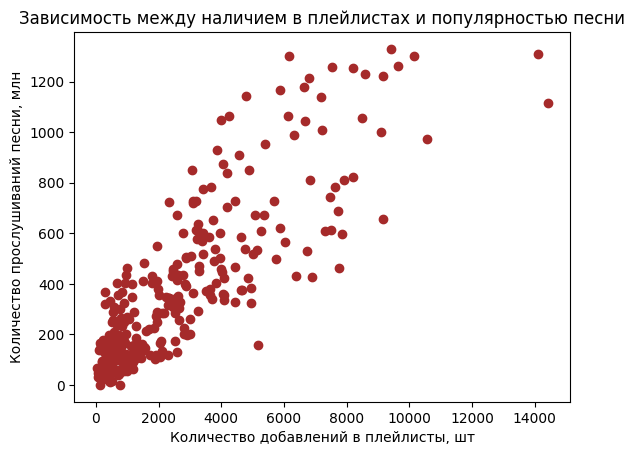

In [ ]:
plt.scatter(df_clean['in_spotify_playlists'], df_clean['streams'].apply(lambda x: x/1000000), color='brown')
plt.xlabel('Количество добавлений в плейлисты, шт')
plt.ylabel('Количество прослушиваний песни, млн')
plt.title('Зависимость между наличием в плейлистах и популярностью песни')

С помощью диаграммы рассеяния можно оценить, есть ли взаимосвязь между признаками. В нашем случае можно заметить положительную связь между количеством плейлистов, в которых содержится трек, и количеством его прослушиваний. Действительно, это легко объяснить логически: чем больше песню добавляют в плейлисты, тем больше у нее прослушиваний.

<Axes: title={'center': 'Динамика среднего общего количества прослушиваний песен за 2018-2023 гг.'}, xlabel='Год выпуска песни', ylabel='Количество прослушиваний, млн'>

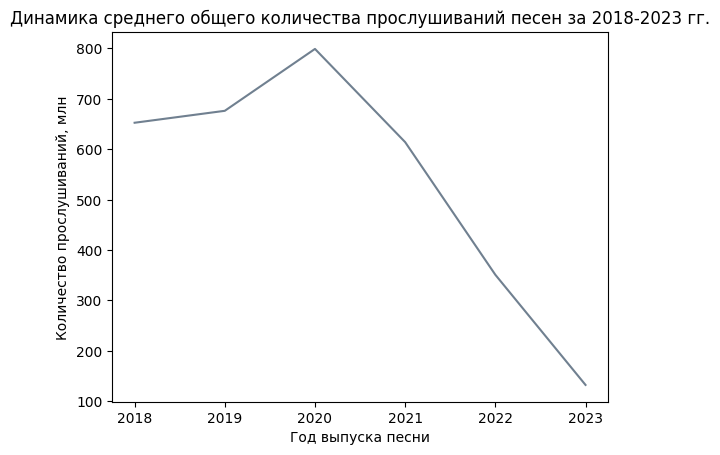

In [ ]:
df_analysis = df_clean.groupby(['released_year'])['streams'].mean().apply(lambda x: x/1000000)
df_analysis.plot(xlabel='Год выпуска песни', ylabel='Количество прослушиваний, млн', title='Динамика среднего общего количества прослушиваний песен за 2018-2023 гг.', color='slategray')

Значение среднего количества прослушиваний со времнем убывает, что можно объяснить спецификой переменной: мы анализируем прослушивания за весь период существования на платформе трека, поэтому песни, выпущенные ранее, в силу времени имеют большее количество прослушиваний. При этом, заметен прирост в 2020 году: это связано с выходом площадки на новый рынок в Россию, из-за чего общее количество прослушиваний сильно увеличилось

<Axes: title={'center': 'Гистограмма распределения количества добавлений в плейлисты'}, xlabel='Количество добавлений в плейлисты, шт', ylabel='Частота признака'>

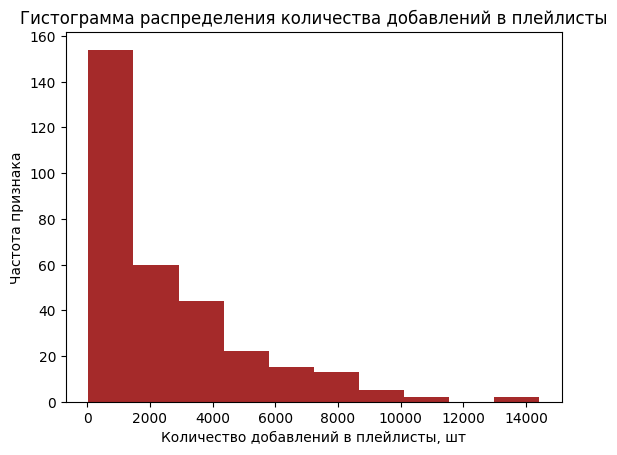

In [ ]:
df_clean['in_spotify_playlists'].plot(xlabel='Количество добавлений в плейлисты, шт', ylabel='Частота признака', title='Гистограмма распределения количества добавлений в плейлисты', kind='hist', color='brown')

Можно заметить, что признак действительно имеет левостороннее распределение, что и предполагалось в описательной статистике.  Большинство песен получают незначительное количество добавлений, что говорит о высокой конкуренции или об ограниченном интересе к большинству треков. Это подтверждает наличие тяжелого хвоста, характерного для музыкальной индустрии: основная масса контента не получает широкой популярности, в то время как небольшая доля треков становится широко известной и собирает существенное количество добавлений.

# Бонус

Гипотеза 1:

Песни с участием нескольких исполнителей (коллаборации) набирают больше прослушиваний, чем песни с одним исполнителем.

Обоснование:
Коллаборации позволяют привлечь аудиторию каждого из исполнителей, что увеличивает охват и число прослушиваний
Платформы, такие как Spotify и Apple Music, активно продвигают коллаборации в плейлистах.
Экономически это связано с кооперативной стратегией, которая позволяет объединить фан-базы и увеличить доходы от стриминга.

Переменные для анализа: streams - найдем среднее значение, artist_count - для связи со средним значением streams

Методология анализа: сравнение средних значений стримов между песнями с разным числом исполнителей (artist_count)

https://vk.com/@zvonkodigital-preimuschestvo-kollaboracii-dlya-artistov - статья рассказывает о том, как коллаборации позволили исполнителям в несколько раз увеличить охваты

Гипотеза 2:

Выпуск треков в определённые месяцы может оказывать влияние на их популярность из-за сезонных факторов, таких как праздники, и крупных ежегодных событий.

Обоснование: В некоторые месяцы охваты песен могут повышаться, если у людей появляется больше свободного времени, что экономически связано с сезонным эффектом повышения спроса

Переменные для анализа: streams - среднее значение по месяцам

Методология анализа: сравнение средних прослушиваний в рекомендованные для выпуска песен месяца и в нерекомендованные.

https://musicconsultant.com/music-career/when-is-the-best-time-of-year-to-release-an-album-or-ep/ - автор описывает, основываясь на своем опыте, в какие месяцы и почему лучше всего выкладывать треки


Гипотеза 3:

Количество добавлений трека в различные плейлисты положительно коррелирует с его позицией в чартах, так как попадание в популярные плейлисты увеличивает видимость и доступность трека для широкой аудитории.

Обоснование: Попадание в музыкальные чарты зависит от количества прослушиваний трека, а в случае большого количества добавлений в плейлисты у песни будут также большое количество прослушиваний.

Переменные для анализа: in_spotify_playlists и in_spotify_charts

Методология анализа: корреляционный анализ


# Корреляция


Построим корреляционную матрицу для всех числовых показателей, так как они могут быть легко интерпретированы.

<Axes: >

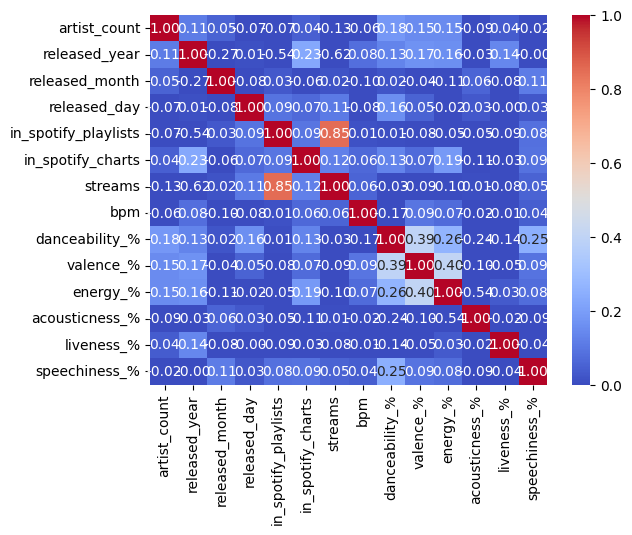

In [ ]:
import seaborn as sns
sns.heatmap(
    data=df_clean.corr(numeric_only=True),
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",)

<Axes: >

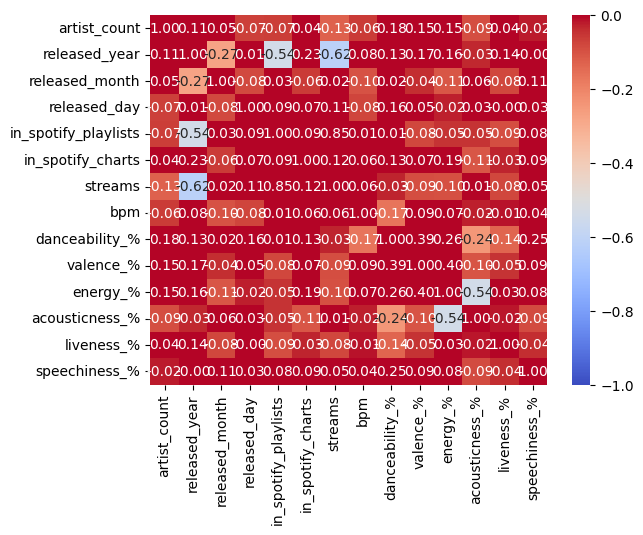

In [ ]:
sns.heatmap(
    data=df_clean.corr(numeric_only=True),
    cmap="coolwarm",
    vmin=-1,
    vmax=0,
    annot=True,
    fmt=".2f",)

Использовано два метода визуализации для более наглядного восприятия информации, а именно: в границах от 0 до 1, чтобы выявить наибольшую положительную связь, и в границах от -1 до 0, чтобы выявить наибольшую отрицательную связь.

Из первой матрицы мы видим, что наибольшая положительная корреляция -  **0.85** наблюдается между **прослушиваниями песни (streams)** и **добавлениями в плейлисты (in_spotify_playlists)**. Эту сильную взаимосвязь можно обьяснить тем, что попадаение трека в оффициальный плейлист способно дать ему сильный буст так, как о нем узнает много новых пользователей, что увеличит количество прослушиваний в разы. Так же и уже популярные треки своими прослушиваниями могут заслуживать места в большем количестве плейлистов, что подтверждает положительную взаимосвязь между переменными (не причинно-следственная). Диаграмма рассеивания для данных переменных уже была построена выше в разделе визуализация.

Из второй матрицы можно выявить наибольшую отрицательную корреляцию: **-0.62** между **количеством прослушиваний (streams)** и **годом выпуска песни (released_year)**. Эта умеренная зависимость может быть объяснена тем, что песни, выпущенные существенное количество времени назад, уже могли стать классическими хитами, набирая стабильно каждый год все больше и больше прослушиваний в то время, как только выпущенные или выпущенные недавно треки, как бы популярны они ни были, чисто физически не могут собрать столько прослушиваний. Ниже представленна диаграмма рассеивания для данных признаков, которая показывает, что самые популярные песни были выпущены в 2020-22 годах, а песни 2023г и, правда, менее популярны, чем предыдущих годов.


Text(0.5, 1.0, 'Зависимость между прослушиваниями песни и годом выпуска')

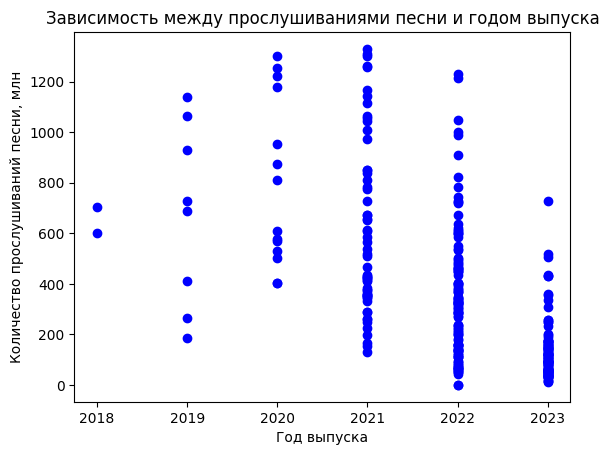

In [ ]:
plt.scatter(df_clean['released_year'], df_clean['streams'].apply(lambda x: x/1000000), color='blue')
plt.xlabel('Год выпуска')
plt.ylabel('Количество прослушиваний песни, млн')
plt.title('Зависимость между прослушиваниями песни и годом выпуска')

#Регрессия

Мы будем строить линейную регрессию, чтобы посмотреть зависимость между **прослушиваниями (streams) - зависимая переменная** и *попаданием трека в чарт (in_spotify_charts), количеством его исполнителей (artist_count), танцевальностью (danceability_%) - независимые переменные*.

In [ ]:
import statsmodels.api as sm
X = sm.add_constant(df_clean[['artist_count', 'in_spotify_charts', 'danceability_%']])
y = df_clean['streams']
model2 = sm.OLS(y, X).fit()
model2.params.map('{:,.0f}'.format)

,0
const,"424,109,535"
artist_count,"-44,258,513"
in_spotify_charts,"2,853,246"
danceability_%,"-584,712"


Интерпретируя коэффициенты регресии, можно отметить следующее: если все предикторы равны 0, то количество прослушиваний будет составлять примерно 424109535. При этом, важно учитывать, что количество исполнителей не может быть 0. С увеличением авторов песни на 1, количество прослушиваний падает на 44258513, с увеличением попадания в чарты на 1 - растет на 2,853,246, а с увеличением уровня танцевальности на 1 - падает на 584,712. Исходя из этого, можно сделать вывод, что рост количества авторов и показателя танцевальности негативно влияет на число прослушиваний трека, а попадание в чарты, наоборот, позитивно.

#Метрики качества регрессии

1. Коэффициент детерминации

In [ ]:
model2.rsquared

np.float64(0.032821314026862725)

Можем увидеть, что коэффициент имеет очень низкое значение, что свидетельствует о том, что модель плохо выполняет свою функцию.

2. Значимость регрессии

In [ ]:
model2.f_pvalue

np.float64(0.01502049622100692)

Так как F-статистика меньше 0.05, можно говорить, что регрессия статистически значима, то есть наша модель обеспечивает лучшее соответствие данным, чем модель, которая не содержит независимых переменных.

3. Среднеквадратичная ошибка (MSE) и среднеабсолютная ошибка (MAE)

In [ ]:
Y_pr = model2.predict(X)
MSE = sum((y-Y_pr)**2)/len(y)
MSE

9.732774353852805e+16

In [ ]:
Y_pr = model2.predict(X)
MAE = sum(abs(y-Y_pr))/len(y)
MAE

242998814.03766528

In [ ]:
r2_linreg = r2_score(y_test, y_pred_test)

Как MSE, так и MAE имеют очень большие значения. Это показывает плохое качество модели.

#Случайный лес

Так как линейная модель показала плохой результат, мы решили воспользоваться нелинейными методами, которые могли бы уловить сложную взаимосвязь между показателями, не доступную для распознавания в линейных моделях.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X = df_clean[['artist_count', 'in_spotify_charts', 'danceability_%']]
y = df_clean['streams']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
rf_model = RandomForestRegressor(n_estimators=1000, max_depth=10, min_samples_split=5, min_samples_leaf=3, random_state=1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=3, min_samples_split=5,
                      n_estimators=1000, random_state=1)

In [ ]:
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

MAE: 231279890.59
MSE: 91168147549329488.00
R²: -0.13


Можно заметить, что случайный лес описывает данные хуже линейной регрессии, а отрицательный коэффициент R^2 говорит о том, что модель слабее даже среднего значения. Настройка параметров также не помогла сделать коэффициент положительным. Исходя из двух моделей, можно сделать вывод, что данные плохо связаны и, видимо, количество прослушиваний слабо зависит от количества исполнителей, уровня танцевальности и количества попаланий в чарты.

# Z и T оценки

In [ ]:
from scipy import stats
import math

gamma = 0.95
n = 317
mean = df_clean['streams'].mean()
sigma = math.sqrt(df_clean['streams'].var())
interval_z = stats.norm.interval(gamma, loc=mean, scale=sigma/np.sqrt(n))
interval_z

(np.float64(317022322.6117832), np.float64(386974222.4544628))

In [ ]:
interval_t = stats.t.interval(gamma, df = n - 1, loc = mean, scale = sigma/np.sqrt(n))
interval_t

(np.float64(316887849.49298173), np.float64(387108695.5732643))

Можно сделать вывод, что истинное математическое ожидание прослушиваний песни на платформе с вероятностью 95% лежит в пределах (317,0 млн; 387,0 млн) по z-оценке и в пределах (316,9 млн; 387,1 млн) по t-оценке. При этом, интервалы очень близки, это следует из большого количества наблюдений и, как следствие, степеней свободы, при которых распределение Стьюдента стремится к нормальному. Так как разница минимальна, можно говорить о стабильности и высокой достоверности результатов.

# Z-test

Для проведения z-теста возьмем все наши данные по признаку streams (прослушивания) и будем считать их выборкой из генеральной совокупности всех прослушиваний за год через сервис Spotify (2015-2024 источник: https://www.businessofapps.com/data/spotify-statistics/ ). Так как генеральная совокупность определена границами 2015-2024 проверим, нет ли в нашей выборке данных, выходящих за границу и удалим их, если есть

In [ ]:
df_clean['streams'].shape[0]

317

In [ ]:
df_clean[df_clean['released_year']>=2015]['streams'].shape[0]

317

Выбросов за 2015 год нет, значит можно перейти к рассчету гипотетического матожидания из представенных ниже данных

Year	Users (mm)
2015.   77
2016.   104
2017.   138
2018.   180
2019.   232
2020.   299
2021.   365
2022.   444
2023.   551
2024.   626










In [ ]:
import statistics
annual=[77,104,138,180,232,299,365,433,551,626]
mu=(statistics.mean(annual))*1000000 #гипотетическое мат.ожидание генеральной выборки в млн прослушиваний. предположим, что дисперсию мы не можем рассчитать и она равна выборке...
mu

300500000.0

Теперь перейдем к нашей выборке и Z-статистике

**Гипотеза:** Если математическое ожидание не равно гипотетическому мат ожиданию, то прослушивания из выборки могут быть накручены. Такой вывод логично вытекает из предположения, что прослушивания треков с 2015 по 2024 складываются в прослушивания уникальных пользователей сквозь эти годы, а значит оба мат одижания стремятся к одному числу.


---


**H_0** : mean = 3606000000

**H_A** : mean ≠ 3606000000


---



In [ ]:
n=len(df_clean['streams']) #размер выборки
mean=df_clean['streams'].mean() #среднее по выборке
std=df_clean['streams'].std() #стандартное отклонение выборки. считаем, что равно генеральной совокупности

In [ ]:
from statsmodels.stats.weightstats import ztest as ztest
res = ztest(df_clean['streams'],
            value = mu,
            alternative = 'two-sided')
print("p_value =",res[1])
print('z-statistics =', res[0])

p_value = 0.003903789223285006
z-statistics = 2.8858332556499424


Получается наша Н_0:

*   отвергается на уровне значимости (α) 1%
*   отвергается на уровне значимости (α) 5%
*   отвергается на уровне значимости (α) 10%

Это говорит о том, что в выборке могут быть накрученные прослушивания, но требуется дальнейшее исследование, так как отклонения могут быть и в меньшую сторону



# T-test

Данная статистика более целесообразна для исследуемой гипотезы так, как наше предположение о равенстве квадратичных отклонений изначально неверно, что в теории не могло не повлиять на эффективность используемого z-метода.  

Чуть изменим нашу гипотезу на одностороннюю для более точного представления о накрутке прослушиваний. То есть: если средние прослушивания по выборке больше средних по генеральной совокупности, то прослушивания накручены.


---


H_0 : mean = 3606000000

H_A : mean > 3606000000


---



In [ ]:
from scipy import stats
res = stats.ttest_1samp(df_clean['streams'],
                        popmean=mu,
                        alternative='greater')
print('p_value =',res[1])
print('t-statistics =',res[0])

p_value = 0.0020862065510142656
t-statistics = 2.8858332556499424


Видим, что Н_0:

*   отвергается на уровне значимости (α) 1%
*   отвергается на уровне значимости (α) 5%
*   отвергается на уровне значимости (α) 10%

При условии, что Н_0 отвергается на всех уровнях значимости, можно сделать вывод, что накрутка прослушиваний точно имела место быть.

# Тест гипотезы о равенстве математических ожиданий двух выборок

В некоторых жанрах традиционно преобладают группы исполнителей, например, в роке, метале, джазе, кантри и прочее([источник](https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D0%BC%D1%83%D0%B7%D1%8B%D0%BA%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%B6%D0%B0%D0%BD%D1%80%D0%BE%D0%B2,_%D0%BD%D0%B0%D0%BF%D1%80%D0%B0%D0%B2%D0%BB%D0%B5%D0%BD%D0%B8%D0%B9_%D0%B8_%D1%81%D1%82%D0%B8%D0%BB%D0%B5%D0%B9)). При этом, данные жанры характеризуются чаще всего средним или высоким BPM, поэтому мы выдвинули гипотезу, что средний уровень BPM песни, созданной в группе, выше той, что написана человеком в одиночку.

** **
**Гипотеза**. Средний уровень BPM у треков музыкальных групп больше, чем у треков одиночных исполнителей.

$$ H_0: \mu^{band} = \mu^{solo} $$

$$ H_A: \mu^{band} > \mu^{solo} $$
** **


Так как объекты наблюдения у нас разные, мы использовали метод для несвязных выборок

Данный метод используется для нормально распределенных величин, поэтому логарифмируем переменную bpm, делим датасет на два в зависимости от количества исполнителей и используем тест Шапира-Уилка для потверждения, что мы привели к нормальному распределению

In [ ]:
df_clean = df_clean.copy()
df_clean['log_bpm'] = df_clean['bpm'].apply(lambda x: np.log(x+1))

df_band = df_clean[df_clean['artist_count'] > 1]
df_solo = df_clean[df_clean['artist_count'] == 1]

In [ ]:
from scipy.stats import shapiro

res = shapiro(df_solo['log_bpm'])
res[1]

np.float64(0.22863228374254563)

In [ ]:
res = shapiro(df_band['log_bpm'])
res[1]

np.float64(0.2529707656515541)

Так как предпосылки выполнены, тестируем гипотезу:

In [ ]:
result = stats.ttest_ind(df_band['bpm'],
                         df_solo['bpm'],
                         alternative = 'greater',
                         equal_var=True)
result

TtestResult(statistic=np.float64(-1.1772850237786379), pvalue=np.float64(0.8800147385903635), df=np.float64(315.0))

Значение t-статистики показывает, что средний BPM у групп немного ниже, чем у сольных исполнителей, но разница слишком мала, чтобы быть статистически значимой. Высокое P-value говорит, что нулевая гипотеза подтверждается на всех адекватных уровнях значимости.
Из этого мы делаем вывод, что наша гипотеза отвергнута, то есть средний BPM песен у групп не выше среднего BPM у одиночных исполнителей

# Критерии независимости и согласия хи-квадрат

### Критерий независимости хи-квадрат

**Гипотеза H_0**: В генеральной совокупности не существует зависимости мужду формой тональности и сезоном выпуска песни.  
**H_A**: Мажорные песни выпускают весной и летом, минорные - зимой и весной.

Создадим новый признак Season для удобства.

In [ ]:
def season(x):
  if x == 12 or x == 1 or x == 2:
    return 'Winter'
  elif x == 3 or x == 4 or x == 5:
    return 'Spring'
  elif x == 6 or x == 7 or x == 8:
    return 'Summer'
  else:
    return 'Autumn'

df_clean['Season'] = df_clean['released_month'].apply(season)
df_clean

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,bpm,mode,danceability_%,valence_%,energy_%,acousticness_%,liveness_%,speechiness_%,log_bpm,Season
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,92,Major,71,61,74,7,10,4,4.532599,Spring
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2,2023,3,16,3090,50,725980112,148,Minor,67,83,76,48,8,3,5.003946,Spring
7,Columbia,Quevedo,1,2023,7,7,714,43,58149378,100,Major,67,26,71,37,11,4,4.615121,Summer
10,un x100to,"Bad Bunny, Grupo Frontera",2,2023,4,17,2876,40,505671438,83,Minor,57,56,72,23,27,5,4.430817,Spring
11,Super Shy,NewJeans,1,2023,7,7,422,55,58255150,150,Minor,78,52,82,18,15,7,5.017280,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,Astronaut In The Ocean,Masked Wolf,1,2019,1,1,7191,0,1138474110,150,Minor,78,47,70,18,15,9,5.017280,Winter
594,Ley Seca,"Anuel Aa, Jhay Cortez",2,2021,9,2,2012,0,355219175,105,Major,76,58,84,10,13,10,4.663439,Autumn
595,Every Summertime,NIKI,1,2021,8,10,1211,2,290228626,79,Major,63,76,67,38,6,4,4.382027,Summer
597,you broke me first,Tate McRae,1,2020,4,17,6638,0,1180094974,124,Major,64,8,37,79,9,5,4.828314,Spring


In [ ]:
ct_o = df_clean.groupby('mode')['Season'].value_counts().unstack()
ct_o

Season,Autumn,Spring,Summer,Winter
mode,,,,
Major,40,55,44,49
Minor,21,38,27,43


$$do f = (R - 1)(C - 1)$$

In [ ]:
alpha = 0.01
dof = (2 - 1)*(4 - 1)
print(dof)
critical_value = 11.34

3


In [ ]:
import scipy.stats
chi_square = scipy.stats.chi2_contingency(ct_o)[0]
chi_square

np.float64(2.5961460733965924)

In [ ]:
chi_square > critical_value

np.False_

**Вывод:** Наблюдаем, что значение хи-квадрата меньше, чем критическое значение. Таким образом, нулевая гипотеза подтврждается, а значит, зависимость между тональностью песен и сезоном их выпуска не подтверждается.

### Критерий согласия хи-квадрат

**Гипотеза H_0**: Все песни выпускаются в равном соотношении между сезонами: 25% приходится на каждый сезон.  
**H_A**: Весной выпускается больше песен чем осенью.

$$do f = C - 1$$

In [ ]:
alpha_1 = 0.05
dof_1 = 4 - 1
print(dof_1)
critical_value_1 = 7.81

3


In [ ]:
print(df_clean.shape[0])
print(df_clean[df_clean['Season'] == 'Winter'].shape[0])
print(df_clean[df_clean['Season'] == 'Spring'].shape[0])
print(df_clean[df_clean['Season'] == 'Summer'].shape[0])
print(df_clean[df_clean['Season'] == 'Autumn'].shape[0])

317
92
93
71
61


Наблюдаемые частоты (***f_0*** — observed frequencies): 317  
$$ f_o = 317$$
$$ f_oзима = 92$$
$$ f_oвесна = 93$$
$$ f_oлето = 71$$
$$ f_oосень = 61$$

Tеоретические частоты (***f_e*** — expected frequencies): 317  
$$ f_e = pn = 1 * 317$$
$$ f_eзима = f_eвесна = f_eлето = f_eосень = 0.25 * 317 = 79.25$$

In [ ]:
f_ow = 92
f_ospr = 93
f_osumm = 71
f_oa = 61
f_ew = 79.25
f_espr = 79.25
f_esumm = 79.25
f_ea = 79.25

In [ ]:
chi_square_1 = ((f_ow-f_ew)**2/f_ew) + ((f_ospr-f_espr)**2/f_espr) + ((f_osumm-f_esumm)**2/f_esumm) + ((f_oa-f_ea)**2/f_ea)
chi_square_1

9.498422712933754

In [ ]:
chi_square_1 > critical_value_1

True

**Вывод**: Нулевая гипотеза о равенствен распределения песен по сезонам может быть отвергнута.